In [1]:
pip install pandas numpy datetime

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Step 1: Data Cleaning, Auditing & EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
print (os.listdir())

['.ipynb_checkpoints', 'Dataset_01.csv', 'Dataset_01_CREDIT_CARD_FRAUD_DETECTION.ipynb', 'Dataset_02_(EU).csv', 'Dataset_02_(EU)_CREDIT_CARD_FRAUD_DETECTION.ipynb', 'Dataset_03.csv', 'Dataset_03_CREDIT_CARD_FRAUD_DETECTION.ipynb']


In [3]:
df_ulb =pd. read_csv('Dataset_02_(EU).csv')
print ("Total Rows & Columns:", df_ulb.shape)
df_ulb.head(3)

Total Rows & Columns: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [5]:
print("Missing Values:", df_ulb.isnull().sum().sum())
print("Duplicate Rows:", df_ulb.duplicated().sum())

print("\nClass Counts:")
print(df_ulb['Class'].value_counts())

print("\nClass Percentages:")
print(df_ulb['Class'].value_counts(normalize=True) * 100)

Missing Values: 0
Duplicate Rows: 1081

Class Counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class Percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [6]:
print("Duplicates Breakdown:")
print(df_ulb[df_ulb.duplicated()]['Class'].value_counts())

df_ulb = df_ulb.drop_duplicates().reset_index(drop=True)

print("\nNew Dataset Shape after removing duplicates:", df_ulb.shape)

Duplicates Breakdown:
Class
0    1062
1      19
Name: count, dtype: int64

New Dataset Shape after removing duplicates: (283726, 31)


In [7]:
time_hours_max = df_ulb['Time'].max() / 3600
print(f"Total Time Duration in Dataset: {time_hours_max:.2f} Hours")

print("\nAmount Statistics Summary:")
print(df_ulb['Amount'].describe())

Total Time Duration in Dataset: 48.00 Hours

Amount Statistics Summary:
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


Normal Transaction Amount Mean: 88.41357475472458
Fraud Transaction Amount Mean : 123.87186046511628


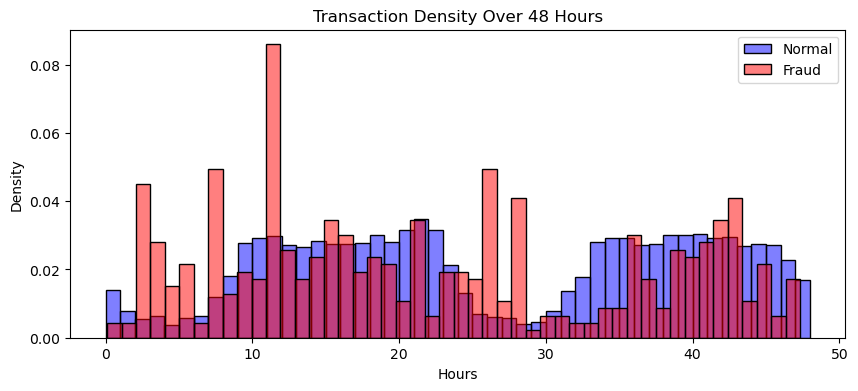

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
# Normal vs Fraud Amount Comparison
print("Normal Transaction Amount Mean:", df_ulb[df_ulb['Class']==0]['Amount'].mean())
print("Fraud Transaction Amount Mean :", df_ulb[df_ulb['Class']==1]['Amount'].mean())

# Plotting Time Distribution for Normal vs Fraud
plt.figure(figsize=(10, 4))
sns.histplot(df_ulb[df_ulb['Class']==0]['Time'] / 3600, bins=48, color='blue', label='Normal', alpha=0.5, stat='density')
sns.histplot(df_ulb[df_ulb['Class']==1]['Time'] / 3600, bins=48, color='red', label='Fraud', alpha=0.5, stat='density')
plt.title('Transaction Density Over 48 Hours')
plt.xlabel('Hours')
plt.ylabel('Density')
plt.legend()
plt.show()

In [9]:
# Step 2: Feature Engineering & Preprocessing

df_ulb['Hour'] = (df_ulb['Time'] / 3600) % 24

df_ulb['Hour_sin'] = np.sin(2 * np.pi * df_ulb['Hour'] / 24.0)
df_ulb['Hour_cos'] = np.cos(2 * np.pi * df_ulb['Hour'] / 24.0)

df_ulb['Amount_log'] = np.log1p(df_ulb['Amount'])

df_ulb[['Time', 'Hour', 'Hour_sin', 'Hour_cos', 'Amount', 'Amount_log']].head(3)

,Time,Hour,Hour_sin,Hour_cos,Amount,Amount_log
0,0.0,0.000000,0.000000,1.0,149.62,5.014760
1,0.0,0.000000,0.000000,1.0,2.69,1.305626
2,1.0,0.000278,0.000073,1.0,378.66,5.939276


In [10]:
features_to_drop = ['Time', 'Amount', 'Hour']
df_ulb_prepared = df_ulb.drop(columns=features_to_drop)

print("Prepared Dataset Shape:", df_ulb_prepared.shape)
print("\nFinal Feature List:")
print(list(df_ulb_prepared.columns))

Prepared Dataset Shape: (283726, 32)

Final Feature List:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Hour_sin', 'Hour_cos', 'Amount_log']


In [11]:
# Chronological Split: Train (70%), Validation (10%), Test (20%)
df_ulb_sorted = df_ulb.sort_values(by='Time').reset_index(drop=True)

features_to_drop = ['Time', 'Amount', 'Hour']
df_sorted = df_ulb_sorted.drop(columns=features_to_drop)

val_idx = int(len(df_sorted) * 0.70)
test_idx = int(len(df_sorted) * 0.80)

X = df_sorted.drop(columns=['Class'])
y = df_sorted['Class']

X_train, y_train = X.iloc[:val_idx], y.iloc[:val_idx]
X_val, y_val = X.iloc[val_idx:test_idx], y.iloc[val_idx:test_idx]
X_test, y_test = X.iloc[test_idx:], y.iloc[test_idx:]

print("=== Step 2 Completed (Train-Val-Test Split) ===")
print(f"Train Shape: {X_train.shape} | Fraud Cases: {y_train.sum()}")
print(f"Val Shape:   {X_val.shape} | Fraud Cases: {y_val.sum()}")
print(f"Test Shape:  {X_test.shape} | Fraud Cases: {y_test.sum()}")

=== Step 2 Completed (Train-Val-Test Split) ===
Train Shape: (198608, 31) | Fraud Cases: 366
Val Shape:   (28372, 31) | Fraud Cases: 33
Test Shape:  (56746, 31) | Fraud Cases: 74


In [12]:
# STEP 3: CLASS IMBALANCE HANDLING

from imblearn.combine import SMOTETomek

print("Running SMOTE-Tomek...")
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print("=== Step 3 Completed ===")
print(f"Original Train Fraud Count: {y_train.sum()}")
print(f"Resampled Train Fraud Count: {y_train_res.sum()}")
print(f"Resampled Training Set Shape: {X_train_res.shape}")

Running SMOTE-Tomek...
=== Step 3 Completed ===
Original Train Fraud Count: 366
Resampled Train Fraud Count: 198242
Resampled Training Set Shape: (396484, 31)


In [13]:
# STEP 4: MODEL TRAINING

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced_subsample'),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6, scale_pos_weight=1, random_state=42, eval_metric='logloss', n_jobs=-1)
}

trained_models = {}
print("===Model Training Started ===")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"-> {name} Completed.")

print("\n=== All Models Trained Successfully ===")

===Model Training Started ===
Training Logistic Regression...
-> Logistic Regression Completed.
Training Random Forest...
-> Random Forest Completed.
Training XGBoost...
-> XGBoost Completed.

=== All Models Trained Successfully ===


=== Step 5 Completed: Unbiased Test Performance ===
              Model  Optimal Threshold (Val)  Test Precision  Test Recall  Test F1-Score  Test AUPRC
Logistic Regression                     0.85          0.0823       0.8649         0.1502      0.7593
      Random Forest                     0.45          0.9483       0.7432         0.8333      0.8187
            XGBoost                     0.85          0.5567       0.7297         0.6316      0.7388

Unbiased Evaluation for Best Model: Random Forest (Val Threshold: 0.45)

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56672
           1     0.9322    0.7432    0.8271        74

    accuracy                         0.9996     56746
   macro avg     0.9659    0.8716    0.9134     56746
weighted avg     0.9996    0.9996    0.9996     56746



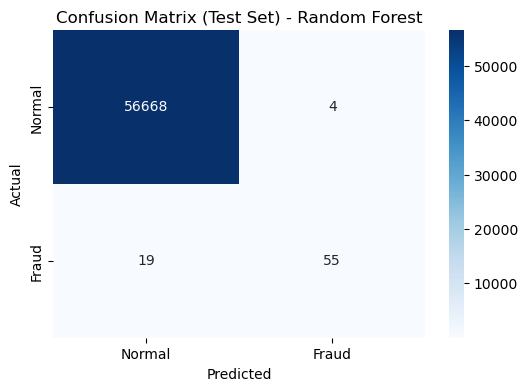

In [14]:
# STEP 5: THRESHOLD OPTIMIZATION (ON VAL) & EVALUATION (ON TEST)
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

eval_results = []

for name, model in trained_models.items():
    # Predict probabilities on Validation and Test sets
    y_proba_val = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_val)
    y_proba_test = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test)
    
    # 1. Optimize threshold on VALIDATION SET
    best_thresh = 0.5
    best_val_f1 = 0
    for thresh in np.arange(0.1, 0.9, 0.05):
        y_pred_val_temp = (y_proba_val >= thresh).astype(int)
        score = f1_score(y_val, y_pred_val_temp)
        if score > best_val_f1:
            best_val_f1 = score
            best_thresh = thresh
            
    # 2. Evaluate on UNSEEN TEST SET using the best threshold from validation
    y_pred_test_opt = (y_proba_test >= best_thresh).astype(int)
    
    prec = precision_score(y_test, y_pred_test_opt)
    rec = recall_score(y_test, y_pred_test_opt)
    f1 = f1_score(y_test, y_pred_test_opt)
    auprc = average_precision_score(y_test, y_proba_test)
    
    eval_results.append({
        "Model": name,
        "Optimal Threshold (Val)": round(best_thresh, 2),
        "Test Precision": round(prec, 4),
        "Test Recall": round(rec, 4),
        "Test F1-Score": round(f1, 4),
        "Test AUPRC": round(auprc, 4)
    })

eval_df = pd.DataFrame(eval_results)
print("=== Step 5 Completed: Unbiased Test Performance ===")
print(eval_df.to_string(index=False))

# Detailed Evaluation & Confusion Matrix for Best Model
best_model_name = eval_df.sort_values(by="Test AUPRC", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_thresh = eval_df[eval_df["Model"] == best_model_name]["Optimal Threshold (Val)"].values[0]

print(f"\n==========================================")
print(f"Unbiased Evaluation for Best Model: {best_model_name} (Val Threshold: {best_thresh})")
print(f"==========================================\n")

y_proba_best = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.predict(X_test)
y_pred_best = (y_proba_best >= best_thresh).astype(int)

print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred_best, digits=4))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix (Test Set) - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Generating SHAP Plot for Best Model: Random Forest


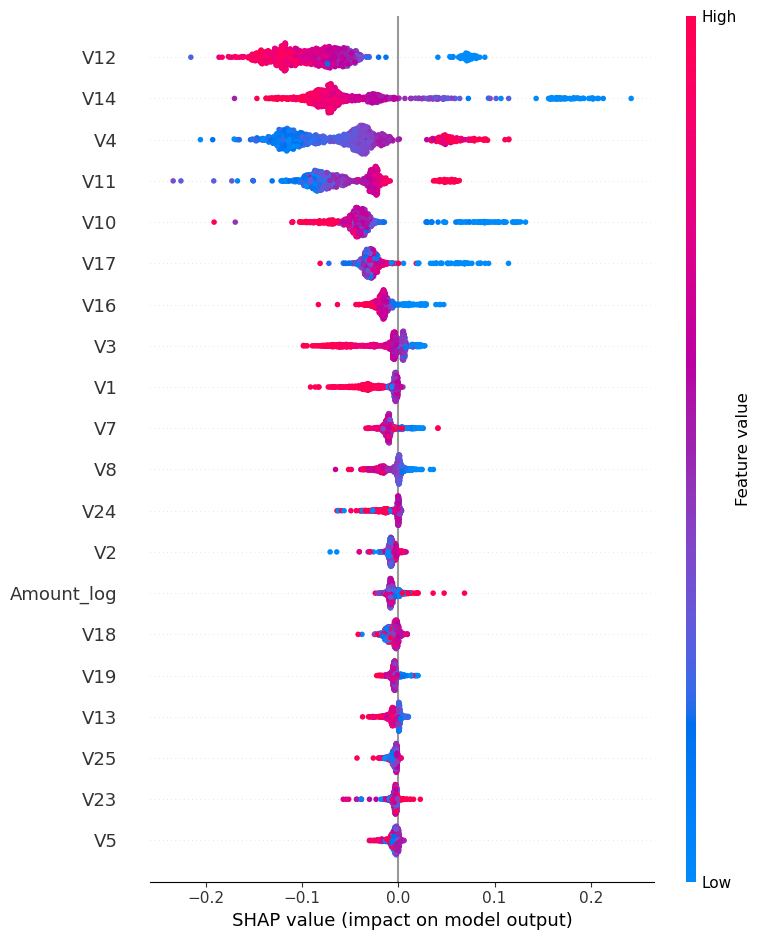

In [16]:
# STEP 6: MODEL EXPLAINABILITY (SHAP ANALYSIS)
import shap
import matplotlib.pyplot as plt

# Identify best performing model based on Test AUPRC
best_model_name = eval_df.sort_values(by="Test AUPRC", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Generating SHAP Plot for Best Model: {best_model_name}")

# Representative sample for SHAP plot
fraud_samples = X_test[y_test == 1]
non_fraud_samples = X_test[y_test == 0].sample(n=1000 - len(fraud_samples), random_state=42)
X_shap_sample = pd.concat([fraud_samples, non_fraud_samples])

explainer = shap.TreeExplainer(best_model) if "Logistic" not in best_model_name else shap.LinearExplainer(best_model, X_train_res)
shap_vals = explainer.shap_values(X_shap_sample)

if isinstance(shap_vals, list):
    shap_to_plot = shap_vals[1]
elif len(np.array(shap_vals).shape) == 3:
    shap_to_plot = shap_vals[:, :, 1]
else:
    shap_to_plot = shap_vals

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_to_plot, X_shap_sample, show=True)